In [36]:
import gdsfactory as gf
from gdsfactory.gpdk import get_generic_pdk
import numpy as np
gf.gpdk.PDK.activate()

In [37]:
@gf.cell
def Taper(length_taper = 10, w_in = 1,  w_out = 1, layer=(1, 0)):
    ''' This code generates a taper '''
    c = gf.Component()
    c.add_polygon([(0, -w_in/2), (length_taper, -(w_in+w_out)/2), (length_taper, (w_in+w_out)/2), (0, w_in/2)], layer=layer)
    c.add_port(name="o1", center=[0, 0], width=w_in, orientation=180, layer=layer,port_type="optical")
    c.add_port(name="o2", center=[length_taper, 0], width=w_out, orientation=0, layer=layer,port_type="optical")
    c.info["length"] = length_taper
    return c

@gf.cell
def Core(l_core = 10, w_core = 1,layer=(1, 0)):
    ''' This code generates the core of the MMI '''
    c = gf.Component()
    c.add_polygon([(0, -w_core/2), (l_core, -w_core/2), (l_core, w_core/2), (0,w_core/2)], layer=layer)
    c.add_port(name="o1", center=[0, 0], width=w_core, orientation=180, layer=layer,port_type="optical")
    c.add_port(name="o2", center=[l_core, 0], width=w_core, orientation=0, layer=layer,port_type="optical")
    c.info["length"] = l_core
    return c


@gf.cell
def MMI(length_taper = 10, w_in = 1,  w_out = 1, sep = 5, l_core = 20, w_core = 10):
    ''' This code generates the complete MMI using a Core and Tapers '''
    c = gf.Component()
    Taper1 = c << Taper(length_taper, w_in,  w_out, layer=(1, 0))
    Taper2 = c << Taper(length_taper, w_in,  w_out, layer=(1, 0))
    Taper2.dmove((0, -sep)) 
    Core_MMI = c << Core(l_core, w_core,layer=(1, 0))
    Core_MMI.dmove((length_taper, -sep/2)) 

    Taper3 = c << Taper(length_taper, w_in,  w_out, layer=(1, 0))
    Taper4 = c << Taper(length_taper, w_in,  w_out, layer=(1, 0))
    
    Taper3.dmirror_x()
    Taper4.dmirror_x()
    Taper3.dmove((l_core + 2*length_taper , 0))
    Taper4.dmove((l_core + 2*length_taper , -sep))

    c.add_port("o1", port=Taper1.ports["o1"],port_type="optical") 
    c.add_port("o2", port=Taper2.ports["o1"],port_type="optical") 
    c.add_port("o3", port=Taper3.ports["o1"], orientation=180,port_type="optical") 
    c.add_port("o4", port=Taper4.ports["o1"], orientation=180,port_type="optical")
    c.info["length"] = l_core + 2*length_taper
    return c

@gf.cell
def HeaterWV(L = 10, w = 0.5, layer=(1, 0)):
    c = gf.Component()
    xs = gf.cross_section.strip(width=w, layer=layer)
    heater = gf.components.straight(length=L, cross_section="heater_metal")
    straight = gf.components.straight(length=L, cross_section=xs)
    
    _heater = c << heater
    _straight = c << straight

    c.add_port("o1", port=straight.ports["o1"],port_type="optical")
    c.add_port("o2", port=straight.ports["o2"],port_type="optical")
    c.add_port("e1", port=heater.ports["e1"],port_type="electrical")
    c.add_port("e2", port=heater.ports["e2"],port_type="electrical")

    return c

In [ ]:
@gf.cell
def Tmzi(Lh = 10, dl = 50):

    """
    Generates a thermally tunable Mach-Zehnder Interferometer (MZI) using gdsfactory.

    Parameters
    ----------
    L : float, optional
        Length of the heater section in each arm (in microns). 

    Structure
    ---------
                       b2_______b3
                      |   asy1   |
                     asx1      asx2
                      |          |
                      b1         b4
               InMMI==|          |==OutMMI
                      b5         b8
                      |          |
                     asx3       asx4
                      |          |
                    dl/2        dl/2
                      |          |
                     b6__________b7
                          asy2
    
    Ports
    -----
    Optical:
        o1, o2 : Input ports (from input MMI)
        o3, o4 : Output ports (from output MMI)

    Electrical:
        e1, e2 : Heater contacts (upper arm)
        e3, e4 : Heater contacts (lower arm)

    Returns
    -------
    gf.Component
        A complete MZI layout with optical and electrical ports.

    """
    Tmzi = gf.Component()
    #-----------------------
    # Componentes base
    #-----------------------
    xs = gf.cross_section.strip(width=0.5, layer=(1, 0))
    bend = gf.components.bend_euler(cross_section=xs)
    straight = gf.components.straight(length=25, cross_section=xs)
    # Definicion de los heaters
    MZIheater = HeaterWV(Lh, 0.5, layer=(1, 0))
    # Definicion diferencia longitud brazos MZI
    dlarm = gf.components.straight(length=dl/2, cross_section=xs)

    # In Out MMI
    InMMI = Tmzi << MMI(length_taper = 3, w_in = 0.5,  w_out = 0.5, sep = 1.5, l_core = 32, w_core = 5)
    OutMMI = Tmzi << MMI(length_taper = 3, w_in = 0.5,  w_out = 0.5, sep = 1.5, l_core = 32, w_core = 5)

    # Bends uper arm superior
    ab1   = Tmzi << bend
    ab2   = Tmzi << bend
    ab3   = Tmzi << bend
    ab4   = Tmzi << bend

    # Bends lower arm inferior
    ab5   = Tmzi << bend
    ab6   = Tmzi << bend
    ab7   = Tmzi << bend
    ab8   = Tmzi << bend

    # Electrical arms
    xe = gf.cross_section.strip(width=2.5, layer=(2, 0))
    eb1   = Tmzi << gf.components.bend_euler(cross_section=xe)
    eb2   = Tmzi << gf.components.bend_euler(cross_section=xe)
    eb3   = Tmzi << gf.components.bend_euler(cross_section=xe)
    eb4   = Tmzi << gf.components.bend_euler(cross_section=xe)

    # Vertical connections
    asx1   = Tmzi.add_ref(gf.components.straight(length=1, cross_section=xs))
    asx2   = Tmzi.add_ref(gf.components.straight(length=1, cross_section=xs))
    asx3   = Tmzi.add_ref(gf.components.straight(length=1, cross_section=xs))
    asx4   = Tmzi.add_ref(gf.components.straight(length=1, cross_section=xs))
    dlx3   = Tmzi << dlarm
    dlx4   = Tmzi << dlarm

    # Horizontal connections (Reemplazar por heaters)
    asy1   = Tmzi <<  MZIheater
    asy2   = Tmzi <<  MZIheater


    ab1.connect("o1", InMMI.ports["o3"])
    ab5.connect("o1", InMMI.ports["o4"], mirror=True)
    asx1.connect("o1", ab1.ports["o2"])
    asx3.connect("o1", ab5.ports["o2"])  # <-  
    dlx3.connect("o1",asx3.ports["o2"])   

    ab2.connect("o2", asx1.ports["o2"])
    ab6.connect("o1", dlx3.ports["o2"]) # <-
    asy1.connect("o1", ab2.ports["o1"])
    asy2.connect("o1", ab6.ports["o2"])

    ab3.connect("o2", asy1.ports["o2"]) 
    ab7.connect("o1", asy2.ports["o2"]) 
    asx2.connect("o2", ab3.ports["o1"])
    asx4.connect("o1", ab7.ports["o2"]) # <-
    dlx4.connect("o1",asx4.ports["o2"])  

    ab4.connect("o1", asx2.ports["o1"])
    ab8.connect("o2", dlx4.ports["o2"]) # <-
    OutMMI.connect("o1", ab4.ports["o2"])
    OutMMI.connect("o2", ab8.ports["o1"])

    # Conexiones heaters
    eb1.connect("o2", asy1.ports["e1"], allow_width_mismatch=True, allow_layer_mismatch = True, allow_type_mismatch=True)
    eb2.connect("o1", asy1.ports["e2"], allow_width_mismatch=True, allow_layer_mismatch = True, allow_type_mismatch=True)
    eb3.connect("o1", asy2.ports["e1"], allow_width_mismatch=True, allow_layer_mismatch = True, allow_type_mismatch=True)
    eb4.connect("o2", asy2.ports["e2"], allow_width_mismatch=True, allow_layer_mismatch = True, allow_type_mismatch=True)

    # Definir puertos
    Tmzi.add_port("o1", port=InMMI.ports["o1"],port_type="optical")
    Tmzi.add_port("o2", port=InMMI.ports["o2"],port_type="optical")
    Tmzi.add_port("o3", port=OutMMI.ports["o3"],port_type="optical")
    Tmzi.add_port("o4", port=OutMMI.ports["o4"],port_type="optical")
    Tmzi.add_port("e1", port=eb1.ports["o1"],port_type="electrical")
    Tmzi.add_port("e2", port=eb2.ports["o2"],port_type="electrical")
    Tmzi.add_port("e3", port=eb3.ports["o2"],port_type="electrical")
    Tmzi.add_port("e4", port=eb4.ports["o1"],port_type="electrical")

    return Tmzi

2026-05-02 14:57:01.860 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/build/oas/3002731577.oas'


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer         ┃ center        ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 0.5   │ 180.0       │ WG (1/0)      │ (0.0, 0.0)    │ optical   │
│ o2   │ 0.5   │ 180.0       │ WG (1/0)      │ (0.0, -1.5)   │ optical   │
│ o3   │ 0.5   │ 0.0         │ WG (1/0)      │ (126.0, 0.0)  │ optical   │
│ o4   │ 0.5   │ 0.0         │ WG (1/0)      │ (126.0, -1.5) │ optical   │
│ e1   │ 2.5   │ 90.0        │ SLAB150 (2/0) │ (48.0, 31.0)  │ optical   │
│ e2   │ 2.5   │ 90.0        │ SLAB150 (2/0) │ (78.0, 31.0)  │ optical   │
│ e3   │ 2.5   │ 270.0       │ SLAB150 (2/0) │ (48.0, -44.0) │ optical   │
│ e4   │ 2.5   │ 270.0       │ SLAB150 (2/0) │ (78.0, -44.0) │ optical   │
└──────┴───────┴─────────────┴───────────────┴───────────────┴───────────┘

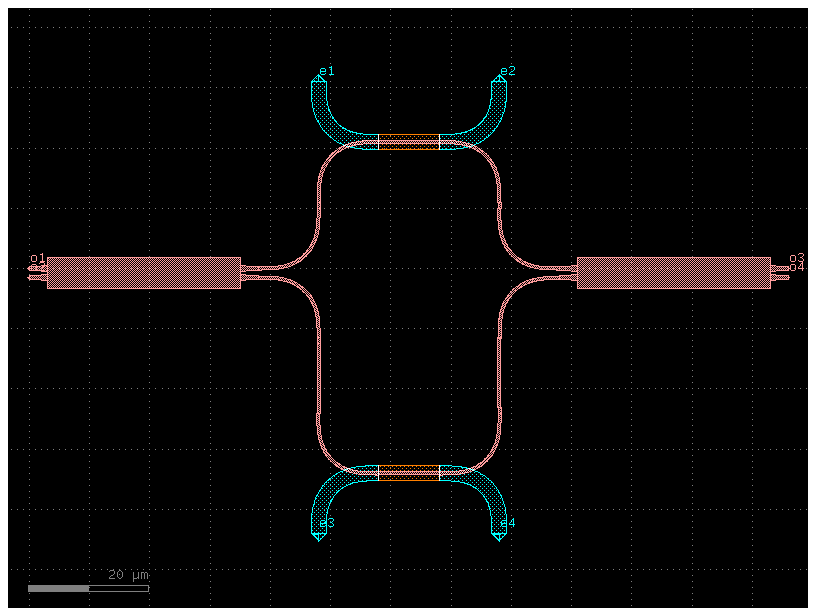

In [39]:
testelemento = Tmzi(Lh=10, dl = 23)
testelemento.draw_ports()
testelemento.plot()
testelemento.show()
testelemento.pprint_ports()

2026-05-02 15:20:29.416 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/build/oas/746618200.oas'


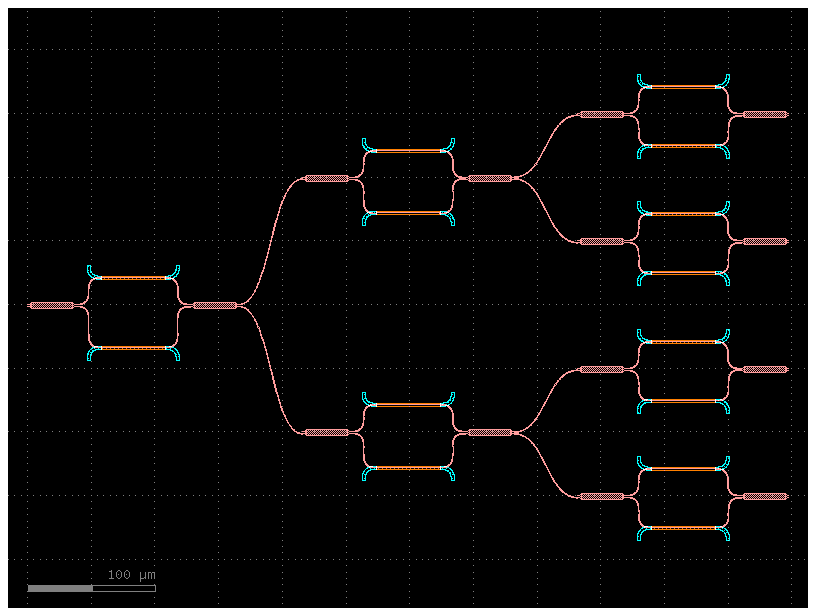

In [56]:
gf.clear_cache()

WDM = gf.Component()
xs = gf.cross_section.strip(width=0.5, layer=(1, 0))
L_FSR = 23  #23
x_sep = 50
Lh = 50 # Longitud heater

#--------------------------------------------
# MZI necesarios para el WDM
#--------------------------------------------

MZI_IN  = WDM << Tmzi(Lh=Lh, dl = L_FSR)

MZI_TP  = WDM << Tmzi(Lh=Lh, dl = L_FSR/2)
MZI_BM  = WDM << Tmzi(Lh=Lh, dl = L_FSR/2)

MZI_4_8 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)
MZI_2_6 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)
MZI_3_7 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)
MZI_1_5 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)

#--------------------------------------------
# Mover los MZI para facilitar su conexión
#--------------------------------------------

# MZI Segunda etapa
MZI_TP.dmovey(MZI_IN.ports["o3"].dy+100).dmovex(MZI_IN.ports["o3"].dx+x_sep)
MZI_BM.dmovey(MZI_IN.ports["o3"].dy-100).dmovex(MZI_IN.ports["o3"].dx+x_sep)

# MZI tercera etapa

MZI_4_8.dmovey(MZI_TP.ports["o3"].dy+50).dmovex(MZI_TP.ports["o3"].dx+x_sep)
MZI_2_6.dmovey(MZI_TP.ports["o3"].dy-50).dmovex(MZI_TP.ports["o3"].dx+x_sep)

MZI_3_7.dmovey(MZI_BM.ports["o3"].dy+50).dmovex(MZI_BM.ports["o3"].dx+x_sep)
MZI_1_5.dmovey(MZI_BM.ports["o3"].dy-50).dmovex(MZI_BM.ports["o3"].dx+x_sep)

#--------------------------------------------
# Mover los MZI para facilitar su conexión
#--------------------------------------------

# Etapa 1 a etapa 2
gf.routing.route_single_sbend(WDM,port1=MZI_IN['o3'], port2=MZI_TP['o2'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=MZI_IN['o4'], port2=MZI_BM['o2'], cross_section=xs)

# Etapa 2 a etapa 3

gf.routing.route_single_sbend(WDM,port1=MZI_TP['o3'], port2=MZI_4_8['o2'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=MZI_TP['o4'], port2=MZI_2_6['o2'], cross_section=xs)

gf.routing.route_single_sbend(WDM,port1=MZI_BM['o3'], port2=MZI_3_7['o2'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=MZI_BM['o4'], port2=MZI_1_5['o2'], cross_section=xs)

WDM.plot()
WDM.show()

Definir función de GDS Factory

In [61]:
def WDM():
    WDM = gf.Component()
    xs = gf.cross_section.strip(width=0.5, layer=(1, 0))
    L_FSR = 23  #23
    x_sep = 50
    Lh = 50 # Longitud heater

    #--------------------------------------------
    # MZI necesarios para el WDM
    #--------------------------------------------

    MZI_IN  = WDM << Tmzi(Lh=Lh, dl = L_FSR)

    MZI_TP  = WDM << Tmzi(Lh=Lh, dl = L_FSR/2)
    MZI_BM  = WDM << Tmzi(Lh=Lh, dl = L_FSR/2)

    MZI_4_8 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)
    MZI_2_6 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)
    MZI_3_7 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)
    MZI_1_5 = WDM << Tmzi(Lh=Lh, dl = L_FSR/4)

    #--------------------------------------------
    # Mover los MZI para facilitar su conexión
    #--------------------------------------------

    # MZI Segunda etapa
    MZI_TP.dmovey(MZI_IN.ports["o3"].dy+100).dmovex(MZI_IN.ports["o3"].dx+x_sep)
    MZI_BM.dmovey(MZI_IN.ports["o3"].dy-100).dmovex(MZI_IN.ports["o3"].dx+x_sep)

    # MZI tercera etapa

    MZI_4_8.dmovey(MZI_TP.ports["o3"].dy+50).dmovex(MZI_TP.ports["o3"].dx+x_sep)
    MZI_2_6.dmovey(MZI_TP.ports["o3"].dy-50).dmovex(MZI_TP.ports["o3"].dx+x_sep)

    MZI_3_7.dmovey(MZI_BM.ports["o3"].dy+50).dmovex(MZI_BM.ports["o3"].dx+x_sep)
    MZI_1_5.dmovey(MZI_BM.ports["o3"].dy-50).dmovex(MZI_BM.ports["o3"].dx+x_sep)

    #--------------------------------------------
    # Mover los MZI para facilitar su conexión
    #--------------------------------------------

    # Etapa 1 a etapa 2
    gf.routing.route_single_sbend(WDM,port1=MZI_IN['o3'], port2=MZI_TP['o2'], cross_section=xs)
    gf.routing.route_single_sbend(WDM,port1=MZI_IN['o4'], port2=MZI_BM['o2'], cross_section=xs)

    # Etapa 2 a etapa 3

    gf.routing.route_single_sbend(WDM,port1=MZI_TP['o3'], port2=MZI_4_8['o2'], cross_section=xs)
    gf.routing.route_single_sbend(WDM,port1=MZI_TP['o4'], port2=MZI_2_6['o2'], cross_section=xs)

    gf.routing.route_single_sbend(WDM,port1=MZI_BM['o3'], port2=MZI_3_7['o2'], cross_section=xs)
    gf.routing.route_single_sbend(WDM,port1=MZI_BM['o4'], port2=MZI_1_5['o2'], cross_section=xs)

    #--------------------------------------------
    # Entradas y salidas opticas del WDM
    #--------------------------------------------

    WDM.add_port(name="in1", port=MZI_IN.ports["o1"])
    WDM.add_port(name="in2", port=MZI_IN.ports["o2"])
    WDM.add_port(name="Out1", port=MZI_1_5["o4"])
    WDM.add_port(name="Out2", port=MZI_2_6["o4"])
    WDM.add_port(name="Out3", port=MZI_3_7["o4"])
    WDM.add_port(name="Out4", port=MZI_4_8["o4"])
    WDM.add_port(name="Out5", port=MZI_1_5["o3"])
    WDM.add_port(name="Out6", port=MZI_2_6["o3"])
    WDM.add_port(name="Out7", port=MZI_3_7["o3"])
    WDM.add_port(name="Out8", port=MZI_4_8["o3"])

    return WDM

2026-05-02 15:28:25.146 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/build/oas/3337355714.oas'


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center          ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in1  │ 0.5   │ 180.0       │ WG (1/0) │ (0.0, 0.0)      │ optical   │
│ in2  │ 0.5   │ 180.0       │ WG (1/0) │ (0.0, -1.5)     │ optical   │
│ Out1 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, -151.5) │ optical   │
│ Out2 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, 48.5)   │ optical   │
│ Out3 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, -51.5)  │ optical   │
│ Out4 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, 148.5)  │ optical   │
│ Out5 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, -150.0) │ optical   │
│ Out6 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, 50.0)   │ optical   │
│ Out7 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, -50.0)  │ optical   │
│ Out8 │ 0.5   │ 0.0         │ WG (1/0) │ (598.0, 150.0)  │ optical   │
└──────┴───────┴─────────────┴──────────┴─────────────────┴───────────┘

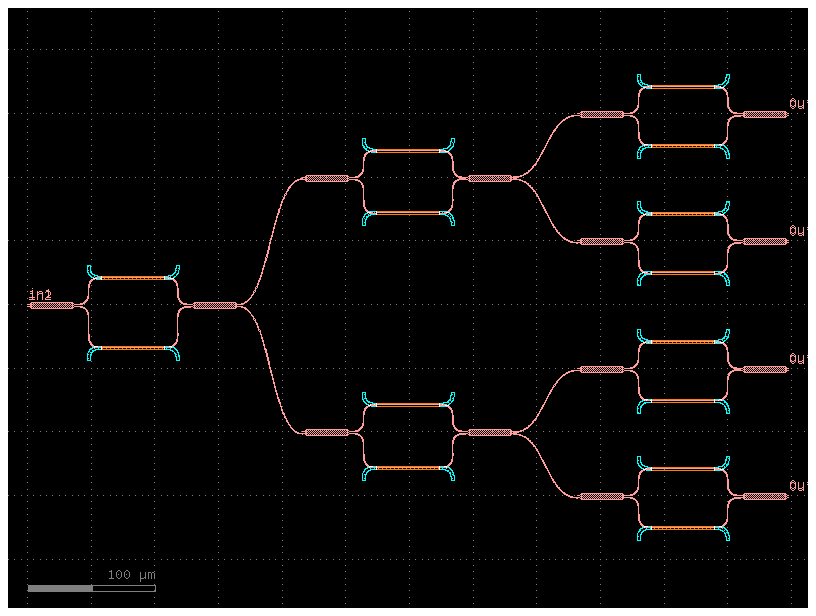

In [62]:
WDM_Test = WDM()
WDM_Test.draw_ports()
WDM_Test.plot()
WDM_Test.show()
WDM_Test.pprint_ports()